# Решающее дерево: диагностика рака молочной железы


## Датасет

Используем `sklearn.datasets.load_breast_cancer`: 30 числовых признаков из биопсий и целевой признак с двумя классами — `0` (malignant, злокачественная) и `1` (benign, доброкачественная).


## Импорт библиотек

Подготовим инструменты для загрузки данных, обучения и визуализации результатов.


In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

RANDOM_STATE = 42


## Загрузка и разбиение данных

Используем стратифицированное разбиение, чтобы сохранить исходные пропорции классов.


In [ ]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((455, 30), (114, 30), (455,), (114,))

## Первичный анализ признаков

Проверим описательные статистики, чтобы увидеть масштабы и вариативность признаков.


In [ ]:
feature_summary = (
    X_train.describe()
    .T[['mean', 'std', 'min', 'max']]
    .rename(columns={"mean": "Mean", "std": "Std", "min": "Min", "max": "Max"})
    .round(2)
)
feature_summary


,Mean,Std,Min,Max
mean radius,14.07,3.50,6.98,28.11
mean texture,19.25,4.41,9.71,39.28
mean perimeter,91.56,24.15,43.79,188.50
mean area,648.54,344.94,143.50,2499.00
mean smoothness,0.10,0.01,0.06,0.14
mean compactness,0.10,0.05,0.02,0.35
mean concavity,0.09,0.08,0.00,0.43
mean concave points,0.05,0.04,0.00,0.20
mean symmetry,0.18,0.03,0.11,0.30
mean fractal dimension,0.06,0.01,0.05,0.10


Решащее дерево устойчиво к различным масштабам признаков, но статистики помогают увидеть разброс и потенциальные выбросы.


In [ ]:
correlation = X_train.corrwith(y_train).sort_values(ascending=False)
correlation


smoothness error           0.070507
texture error              0.023917
mean fractal dimension    -0.001027
symmetry error            -0.012765
fractal dimension error   -0.059216
concavity error           -0.252785
compactness error         -0.291239
worst fractal dimension   -0.327308
mean symmetry             -0.358370
mean smoothness           -0.392200
mean texture              -0.409384
concave points error      -0.418560
worst smoothness          -0.429227
worst symmetry            -0.430422
worst texture             -0.450765
perimeter error           -0.551905
radius error              -0.565074
area error                -0.567197
worst compactness         -0.602331
mean compactness          -0.610722
worst concavity           -0.668368
mean concavity            -0.692052
mean area                 -0.713409
mean radius               -0.732224
worst area                -0.737965
mean perimeter            -0.745132
worst radius              -0.776390
mean concave points       -0

Корреляции показывают, какие признаки связаны с целевой переменной: положительные значения усиливают вероятность класса `benign`, отрицательные — `malignant`.


## Баланс классов

Проанализируем, насколько много примеров каждого класса.


In [ ]:
class_balance = pd.DataFrame({
    "count": y_train.value_counts().sort_index(),
    "share": (y_train.value_counts(normalize=True).sort_index() * 100).round(2)
}).rename(index={0: "malignant", 1: "benign"})
class_balance


,count,share
target,,
malignant,170,37.36
benign,285,62.64


Доли классов примерно 40/60 в пользу доброкачественных опухолей. Ошибки на меньшем классе `malignant` особенно критичны, поэтому фокусируемся на его качестве.


## Обучение решающего дерева

Ограничим глубину и размер листа, чтобы получить интерпретируемую модель без переобучения.


In [ ]:
tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
y_proba_malignant = tree.predict_proba(X_test)[:, 0]
y_test_malignant = (y_test == 0).astype(int)
y_pred_malignant = (y_pred == 0).astype(int)


### Как дерево выбирает разбиения

На каждом узле дерево перебирает признаки и пороги, чтобы увеличить чистоту классов.
Используется критерий Джини — мера неоднородности узла: $G = 1 - \sum_k p_k^2$, где $p_k$ — доля объектов класса $k$ в узле.
Если узел содержит элементы одного класса, $G = 0$ (полная чистота). Чем сильнее перемешаны классы, тем больше $G$.

Альтернативный критерий — энтропия ($H = -\sum_k p_k \log_2 p_k$): она тоже равна нулю для чистых узлов и растёт, когда классы смешиваются.
scikit-learn по умолчанию использует Джини, потому что он быстрее вычисляется, но при желании можно выбрать `criterion='entropy'`.
Для каждого кандидата разбиения считается взвешенное значение выбранного критерия для дочерних узлов, и выбирается тот порог, который даёт наибольшее снижение нечистоты.


## Ключевые метрики

Сфокусируемся на качестве распознавания злокачественных опухолей.


In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test_malignant, y_pred_malignant)
rec = recall_score(y_test_malignant, y_pred_malignant)
f1 = f1_score(y_test_malignant, y_pred_malignant)
auc = roc_auc_score(y_test_malignant, y_proba_malignant)

print(f"Accuracy: {acc:.3f}")
print(f"Precision (malignant): {prec:.3f}")
print(f"Recall (malignant): {rec:.3f}")
print(f"F1-score (malignant): {f1:.3f}")
print(f"ROC-AUC (malignant): {auc:.3f}")


Accuracy: 0.921
Precision (malignant): 0.884
Recall (malignant): 0.905
F1-score (malignant): 0.894
ROC-AUC (malignant): 0.937


In [ ]:
print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))


              precision    recall  f1-score   support

   malignant       0.88      0.90      0.89        42
      benign       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



Высокий **recall** означает, что дерево почти не пропускает злокачественные случаи. **Precision** показывает, насколько редко модель тревожит пациентов зря. **F1** удерживает баланс, **accuracy** отражает общую долю верных ответов, а **ROC-AUC** ≈ 1 подтверждает уверенное ранжирование по вероятностям.


## Матрица ошибок

Визуализируем типы ошибок.


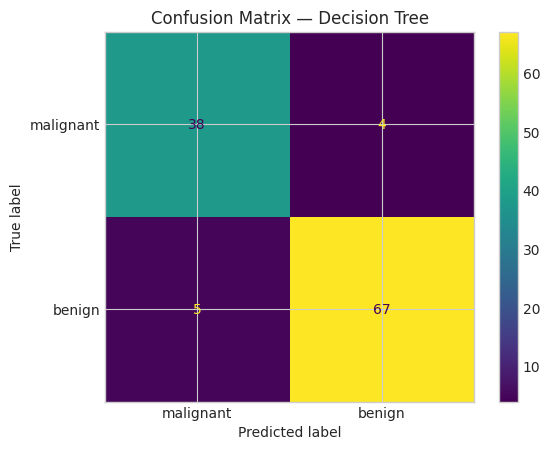

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["malignant", "benign"])
disp.plot(values_format='d')
plt.title("Confusion Matrix — Decision Tree")
plt.show()


Ложных отрицаний (malignant → benign) немного — значит, опасные случаи почти не упускаются. Ложные тревоги (benign → malignant) тоже редки, поэтому система не перегружает врачей.


## ROC-кривая

Посмотрим на компромисс между чувствительностью и специфичностью при разных порогах.


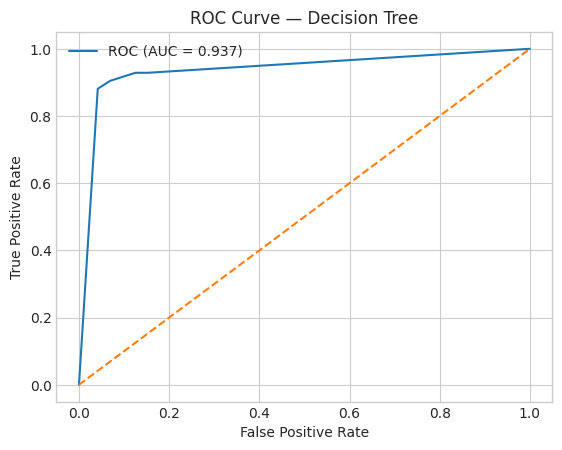

In [ ]:
fpr, tpr, thr = roc_curve(y_test_malignant, y_proba_malignant)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Decision Tree")
plt.legend()
plt.show()


Кривая проходит высоко над диагональю, что подтверждает высокое качество ранжирования.


## Важность признаков

Решающие деревья оценивают вклад признаков через Gini-важность — насколько часто признак используется для чистого разделения классов.


In [ ]:
importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": tree.feature_importances_
    })
    .sort_values("importance", ascending=False)
)
importance.head(10)


,feature,importance
20,worst radius,0.746495
27,worst concave points,0.124181
11,texture error,0.046593
21,worst texture,0.039081
26,worst concavity,0.017464
24,worst smoothness,0.010549
23,worst area,0.008188
13,area error,0.007450
5,mean compactness,0.000000
4,mean smoothness,0.000000


Топ-10 признаков показывает, какие измерения сильнее всего влияют на принадлежность к классу `malignant`. Отрицательные корреляции из EDA хорошо согласуются с высокой важностью.


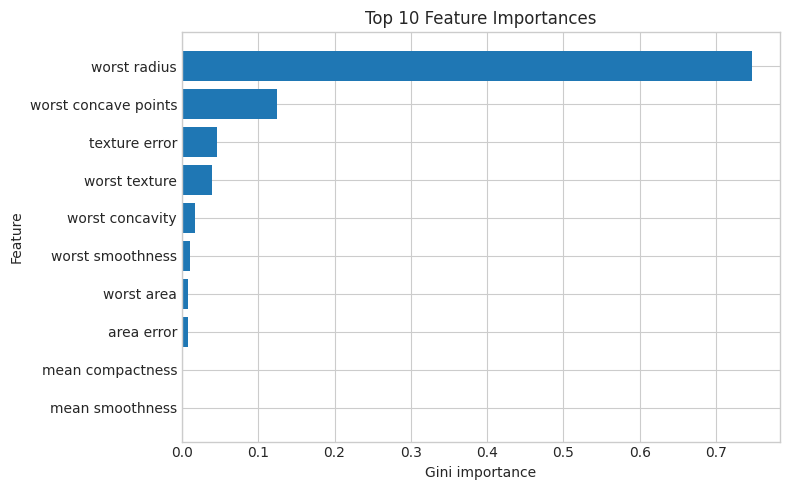

In [ ]:
plt.figure(figsize=(8, 5))
top10 = importance.head(10)[::-1]
plt.barh(top10['feature'], top10['importance'])
plt.title("Top 10 Feature Importances")
plt.xlabel("Gini importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Горизонтальная диаграмма подчёркивает, какие признаки чаще всего попадают в верхние уровни дерева.


## Фрагмент дерева решений

Посмотрим на первые уровни: они задают основные правила разделения.


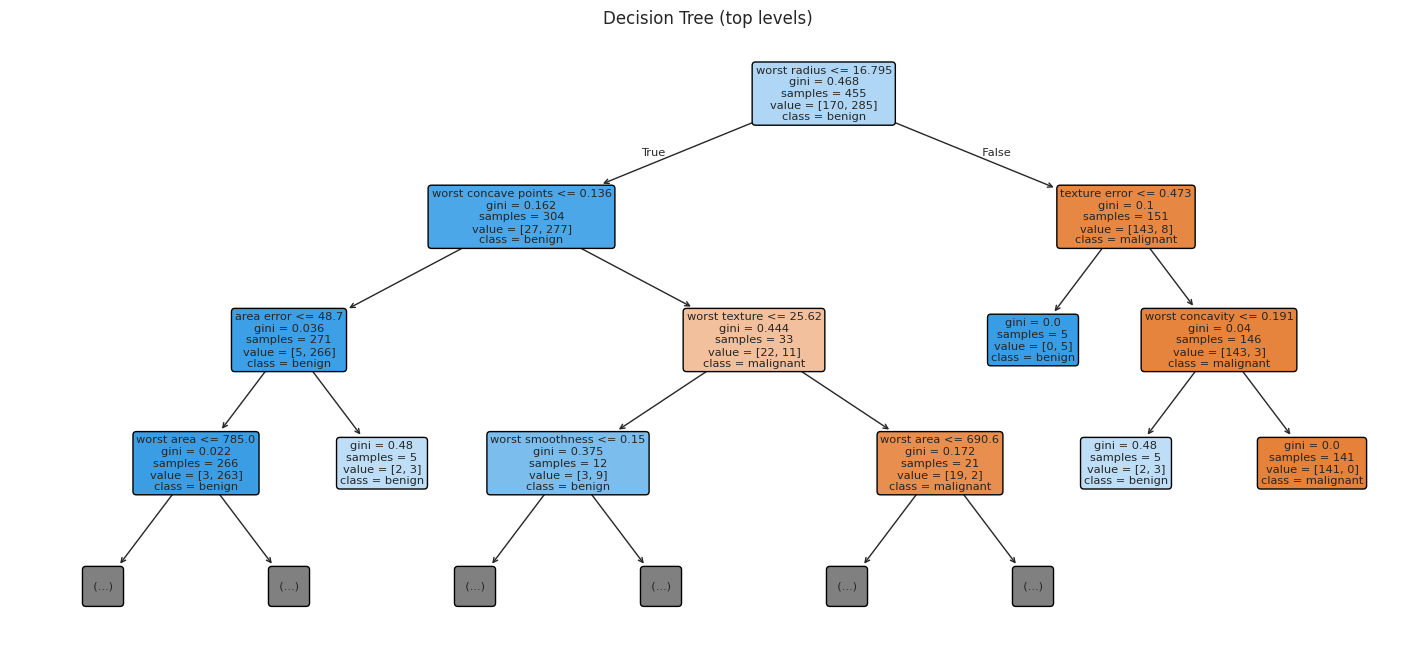

In [ ]:
plt.figure(figsize=(18, 8))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["malignant", "benign"],
    filled=True,
    rounded=True,
    impurity=True,
    max_depth=3
)
plt.title("Decision Tree (top levels)")
plt.show()


Верхние узлы опираются на признаки `worst radius` и `worst concave points`. Пороговые значения можно трактовать как простые диагностические правила.


## Выводы

Решащее дерево даёт интерпретируемые правила и высокое качество на тесте. Дальше можно подбирать гиперпараметры или перейти к ансамблям (Random Forest, Gradient Boosting).
